# 01. Data Understanding - Home Loan Approval Prediction

**Project Goal
Predict whether a loan application will be approved ('Loan_Status = Y/N') based on applicant information.

**Notebook Objective
- Understand the structure of the dataset
- Examine data types, missing values, and basic statistics
- Analyze the target variable
- Form initial hypotheses

**Datasets
- 'train.csv - used for training and analysis (has 'Loan_Status')
- 'test.csv - used for final prediction (no 'Loan_Status')

In [40]:
#=== 1. Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10,6)

print("Libraries loaded successfully,")

Libraries loaded successfully,


In [41]:
#=== 2. Load Data

train = pd.read_csv('../data/raw/train.csv')
test = pd.read_csv('../data/raw/test.csv')

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (614, 13)
Test shape: (367, 12)


In [42]:
#=== 3. First Look at the Data
print ("=== First 5 rows of Train ===")
display (train.head())

print ("\n=== First 5 rows of Test ===")
display(test.head())


=== First 5 rows of Train ===


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y



=== First 5 rows of Test ===


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,NaN,Urban
4,LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban


In [43]:
# === 4. Column Information
print("=== Train Info ===")
train.info()

print("\n=== Test Info ===")
test.info()

=== Train Info ===
<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 83.4 KB

=== Test Info ===
<class 'pandas.DataFrame'>
RangeIndex: 367 entries, 0 to 366
Data columns (total 12 colum

In [44]:
# === 5. Missing Values ===
print ("=== Missing Values in Train ===")
missing_train = train.isnull().sum()
missing_train = missing_train[missing_train > 0]
missing_train = missing_train.sort_values(ascending=False)
print(missing_train)
print("\nTotal missing values in train:", train.isnull().sum().sum())

print ("\n=== Missing Values in Test ===")
missing_test = test.isnull().sum()
missing_test = missing_test[missing_test >0]
missing_test = missing_test.sort_values(ascending=False)
print(missing_test)
print("\nTotal missing values in test:", test.isnull().sum().sum())



=== Missing Values in Train ===
Credit_History      50
Self_Employed       32
LoanAmount          22
Dependents          15
Loan_Amount_Term    14
Gender              13
Married              3
dtype: int64

Total missing values in train: 149

=== Missing Values in Test ===
Credit_History      29
Self_Employed       23
Gender              11
Dependents          10
Loan_Amount_Term     6
LoanAmount           5
dtype: int64

Total missing values in test: 84


=== Loan Status Distribution ===
Loan_Status
Y    422
N    192
Name: count, dtype: int64

Percentage:
Loan_Status
Y    68.7
N    31.3
Name: proportion, dtype: float64


C:\Users\HP\AppData\Local\Temp\ipykernel_5988\1444850974.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train, x='Loan_Status', palette='Set2')


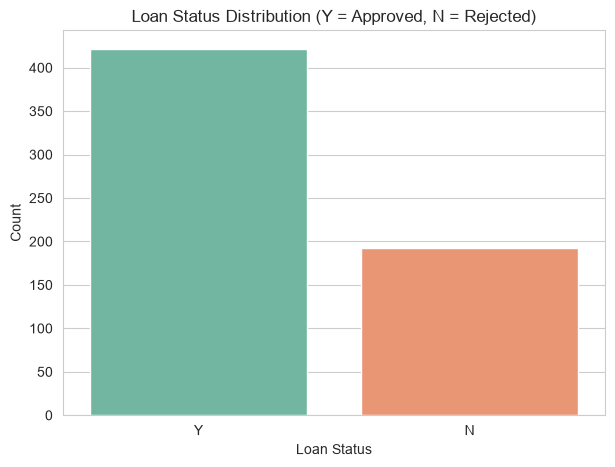

In [45]:
# === 6. Target Variable Analysis
print("=== Loan Status Distribution ===")
print(train['Loan_Status'].value_counts())
print("\nPercentage:")
print(train['Loan_Status'].value_counts(normalize=True).round(3) * 100)

#Vizualization
plt.figure(figsize=(7,5))
sns.countplot(data=train, x='Loan_Status', palette='Set2')
plt.title('Loan Status Distribution (Y = Approved, N = Rejected)')
plt.xlabel('Loan Status')
plt.ylabel('Count')
plt.show()

In [46]:
# Numerical Features Summary
print("=== Numerical Features Summary ===")
display(train.describe())

=== Numerical Features Summary ===


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [47]:
#=== 8. Categorical Features
categorical_cols = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area', 'Credit_History']
print("=== Unique values in Categorical Featres ===")
for col in categorical_cols:
    print(f"\n{col}:")
    print(train[col].value_counts(dropna=False))

=== Unique values in Categorical Featres ===

Gender:
Gender
Male      489
Female    112
NaN        13
Name: count, dtype: int64

Married:
Married
Yes    398
No     213
NaN      3
Name: count, dtype: int64

Dependents:
Dependents
0      345
1      102
2      101
3+      51
NaN     15
Name: count, dtype: int64

Education:
Education
Graduate        480
Not Graduate    134
Name: count, dtype: int64

Self_Employed:
Self_Employed
No     500
Yes     82
NaN     32
Name: count, dtype: int64

Property_Area:
Property_Area
Semiurban    233
Urban        202
Rural        179
Name: count, dtype: int64

Credit_History:
Credit_History
1.0    475
0.0     89
NaN     50
Name: count, dtype: int64


### Initial Observations
1. The target variable ('Loan_Status')is imbalanced - more loans are approved (Y) than rejected (N).
2. Several columns have missing values (especiall Credit_History, Self_Employed, LoanAmount, etc).
3. 'Dependents' contains the value "3_" which is not very reliable and might need special handling.
4. 'Credit_History' looks likea very important feature (only 0 and 1).
5. Income and LoanAmount columns show large variation and possible outliers.

**Next: Notebook 02. Data Cleaning.